# Task 4 — Cross-Dataset Evaluation

Evaluates each trained model on datasets it was **not** trained on, measuring cross-domain generalisation.

| Model | Architecture | Trained on | Cross-tested on |
|-------|-------------|-----------|----------------|
| Classifier | EfficientNet-B4 | HistoricalCrack | CrackForest, Masonry |
| Segmentor | U-Net + ResNet34 | Masonry + CrackForest | HistoricalCrack (qualitative) |
| Detector | YOLOv8s | OmniCrack30k | CrackForest, Masonry |

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4 GPU"
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.10.0+cu128


In [2]:
!pip install -q segmentation-models-pytorch albumentations==1.4.3 ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.5 MB/s eta 0:00:00


## Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
CKPT_DIR  = Path('/content/checkpoints')
OUT_DIR   = Path('/content/cross_eval')

for d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Drive contents:")
for f in sorted(DRIVE_DIR.iterdir()):
    print(f"  {f.name}")

Mounted at /content/drive
Drive contents:
  checkpoints
  crackforest.zip
  historical_crack.zip
  masonry.zip
  notebooks
  omnicrack30k.zip
  plots


In [4]:
import zipfile, shutil

for zip_name, out_name in [
    ('crackforest.zip',      'crackforest'),
    ('masonry.zip',          'masonry'),
    ('historical_crack.zip', 'historical_crack'),
]:
    out_dir = DATA_DIR / out_name
    if out_dir.exists() and any(out_dir.rglob('*.*')):
        print(f"{out_name:20s}: already extracted")
    else:
        print(f"Unzipping {zip_name}...")
        with zipfile.ZipFile(DRIVE_DIR / zip_name) as zf:
            zf.extractall(DATA_DIR)
        print(f"  Done.")

for name, path in [
    ('crackforest/images',       DATA_DIR / 'crackforest' / 'images'),
    ('masonry/images',           DATA_DIR / 'masonry' / 'images'),
    ('historical_crack/cracked', DATA_DIR / 'historical_crack' / 'cracked'),
    ('historical_crack/intact',  DATA_DIR / 'historical_crack' / 'intact'),
]:
    n = len(list(Path(path).glob('*.*'))) if Path(path).exists() else 0
    print(f"{name:35s}: {n}")

Unzipping crackforest.zip...
  Done.
Unzipping masonry.zip...
  Done.
Unzipping historical_crack.zip...
  Done.
crackforest/images                 : 118
masonry/images                     : 240
historical_crack/cracked           : 757
historical_crack/intact            : 3139


In [5]:
checkpoints = [
    ('classifier/best.pth', 'classifier/best.pth'),
    ('segmentor/best.pth',  'segmentor/best.pth'),
    ('detector/best.pt',    'detector/best.pt'),
]

for drive_rel, local_rel in checkpoints:
    src_path = DRIVE_DIR / 'checkpoints' / drive_rel
    dst_path = CKPT_DIR / local_rel
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    if dst_path.exists():
        print(f"Exists  {local_rel}  ({dst_path.stat().st_size / 1e6:.1f} MB)")
    elif src_path.exists():
        print(f"Copying {local_rel}...")
        shutil.copy2(src_path, dst_path)
        print(f"  Done  ({dst_path.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"WARNING: {src_path} not found!")

Copying classifier/best.pth...
  Done  (70.9 MB)
Copying segmentor/best.pth...
  Done  (97.9 MB)
Copying detector/best.pt...
  Done  (22.5 MB)


## 1. Classifier — Cross-Dataset Evaluation

**Model:** EfficientNet-B4 (trained on HistoricalCrack: cracked vs intact)  
**Cross-tested on:** CrackForest (118 images, all cracked), Masonry (240 images, all cracked)

Since these datasets contain only cracked images, the key metric is **recall** — the fraction the model correctly classifies as cracked.

In [6]:
import cv2, numpy as np
import torch.nn as nn
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

DEVICE        = torch.device('cuda')
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
CLS_CLASSES   = ['intact', 'cracked']   # 0=intact, 1=cracked
CLS_IMG_SIZE  = 380


def cls_eval_transform(img_size=CLS_IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


class SingleClassDataset(Dataset):
    """Flat image directory — all images share the same gt_label."""
    def __init__(self, img_dir, gt_label=1, transform=None):
        d = Path(img_dir)
        self.paths     = sorted(d.glob('*.jpg')) + sorted(d.glob('*.png'))
        self.label     = gt_label
        self.transform = transform or cls_eval_transform()

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(image=img)['image'], self.label


def run_classifier(model, img_dir, gt_label=1, batch_size=16, desc=''):
    ds = SingleClassDataset(img_dir, gt_label=gt_label)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    all_preds, all_probs = [], []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc=desc, leave=False):
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(probs.argmax(axis=1))
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    recall    = float((all_preds == gt_label).mean())
    return {'paths': ds.paths, 'preds': all_preds, 'probs': all_probs,
            'recall': recall, 'n': len(ds)}


# ── Load classifier ──────────────────────────────────────────────────────
clf_model = models.efficientnet_b4(weights=None)
clf_model.classifier[1] = nn.Linear(
    clf_model.classifier[1].in_features, len(CLS_CLASSES))
ckpt = torch.load(CKPT_DIR / 'classifier/best.pth', map_location=DEVICE)
clf_model.load_state_dict(ckpt['model_state'])
clf_model.to(DEVICE).eval()
print(f"Classifier loaded  epoch={ckpt['epoch']}  val_f1={ckpt['val_f1']:.4f}")

Classifier loaded  epoch=9  val_f1=0.9826


In [7]:
print('=== CrackForest (118 images, GT=cracked) ===')
cf_res = run_classifier(clf_model, DATA_DIR / 'crackforest/images',
                        gt_label=1, desc='CrackForest')
print(f"N images         : {cf_res['n']}")
print(f"Recall (cracked) : {cf_res['recall']:.4f}")
print(f"Mean P(cracked)  : {cf_res['probs'][:, 1].mean():.4f}")
print(f"Predicted cracked: {(cf_res['preds'] == 1).sum()} / {cf_res['n']}")

print()
print('=== Masonry (240 images, GT=cracked) ===')
ms_res = run_classifier(clf_model, DATA_DIR / 'masonry/images',
                        gt_label=1, desc='Masonry')
print(f"N images         : {ms_res['n']}")
print(f"Recall (cracked) : {ms_res['recall']:.4f}")
print(f"Mean P(cracked)  : {ms_res['probs'][:, 1].mean():.4f}")
print(f"Predicted cracked: {(ms_res['preds'] == 1).sum()} / {ms_res['n']}")

=== CrackForest (118 images, GT=cracked) ===


CrackForest:   0%|          | 0/8 [00:00<?, ?it/s]

N images         : 118
Recall (cracked) : 0.8983
Mean P(cracked)  : 0.8993
Predicted cracked: 106 / 118

=== Masonry (240 images, GT=cracked) ===


Masonry:   0%|          | 0/15 [00:00<?, ?it/s]

N images         : 240
Recall (cracked) : 0.7667
Mean P(cracked)  : 0.7616
Predicted cracked: 184 / 240


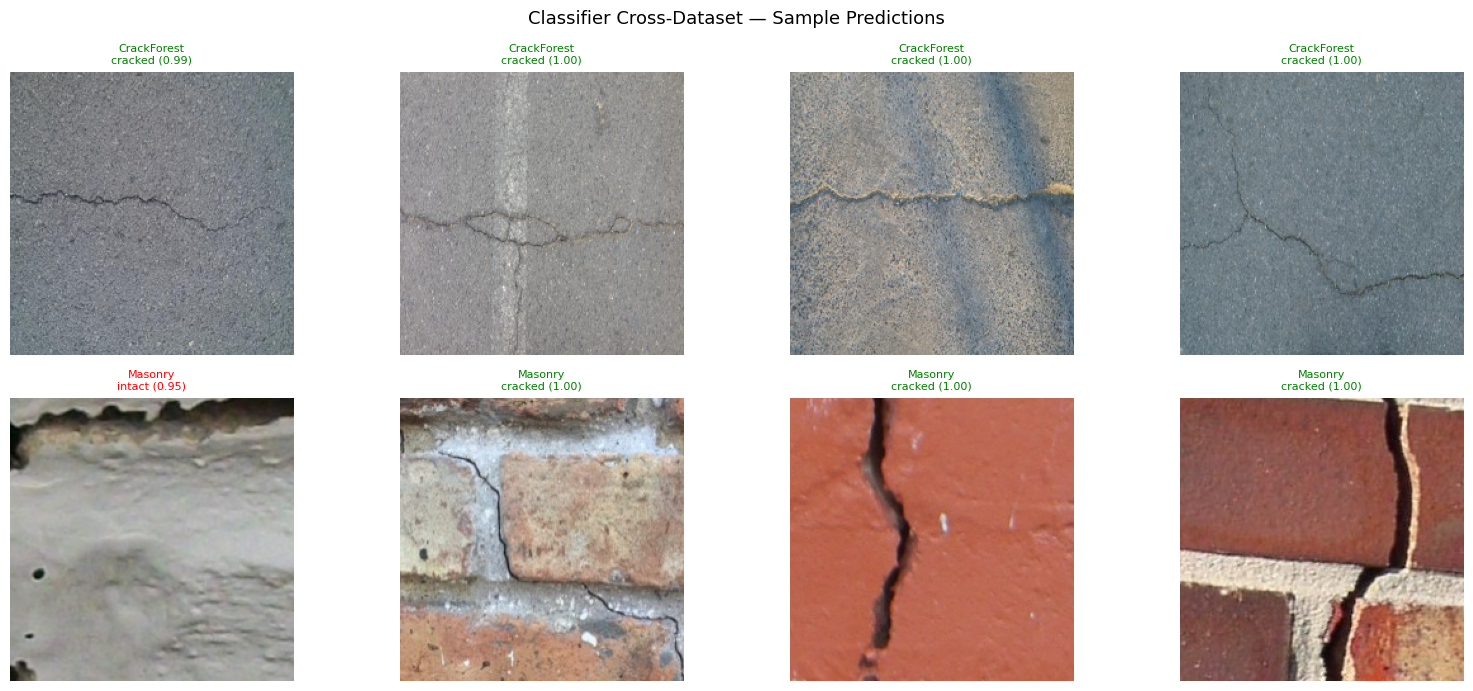

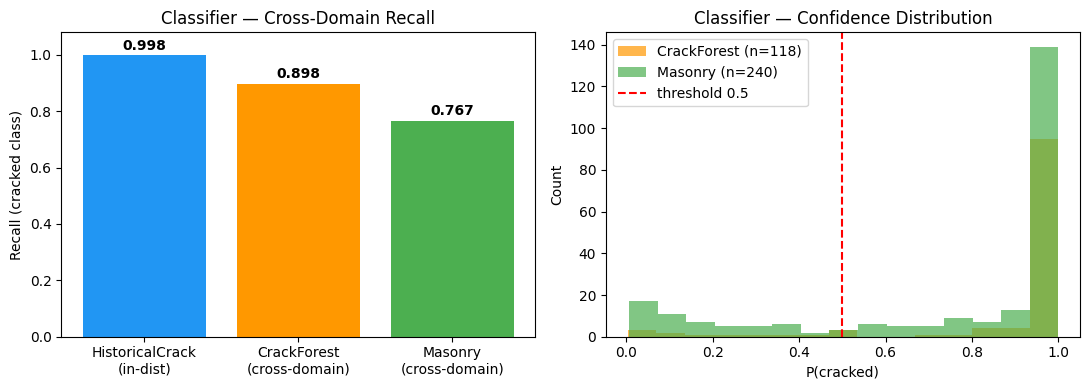

In [8]:
import random

# ── Sample prediction grid ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Classifier Cross-Dataset — Sample Predictions', fontsize=13)

for row, (res, title) in enumerate([
    (cf_res, 'CrackForest'),
    (ms_res, 'Masonry'),
]):
    idxs = random.sample(range(len(res['paths'])), min(4, len(res['paths'])))
    for col, idx in enumerate(idxs):
        img = cv2.imread(str(res['paths'][idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        pred  = CLS_CLASSES[res['preds'][idx]]
        conf  = res['probs'][idx, res['preds'][idx]]
        color = 'green' if res['preds'][idx] == 1 else 'red'
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{title}\n{pred} ({conf:.2f})",
                                  fontsize=8, color=color)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'clf_cross_predictions.png', dpi=150)
plt.show()

# ── Summary charts ───────────────────────────────────────────────────────
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

datasets_names = ['HistoricalCrack\n(in-dist)', 'CrackForest\n(cross-domain)', 'Masonry\n(cross-domain)']
recalls  = [0.9983, cf_res['recall'], ms_res['recall']]
colors   = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax1.bar(datasets_names, recalls, color=colors)
ax1.set_ylim(0, 1.08)
ax1.set_ylabel('Recall (cracked class)')
ax1.set_title('Classifier — Cross-Domain Recall')
for bar, val in zip(bars, recalls):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.hist(cf_res['probs'][:, 1], bins=15, alpha=0.7,
         label=f"CrackForest (n={cf_res['n']})", color='#FF9800')
ax2.hist(ms_res['probs'][:, 1], bins=15, alpha=0.7,
         label=f"Masonry (n={ms_res['n']})", color='#4CAF50')
ax2.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='threshold 0.5')
ax2.set_xlabel('P(cracked)')
ax2.set_ylabel('Count')
ax2.set_title('Classifier — Confidence Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'clf_cross_summary.png', dpi=150)
plt.show()

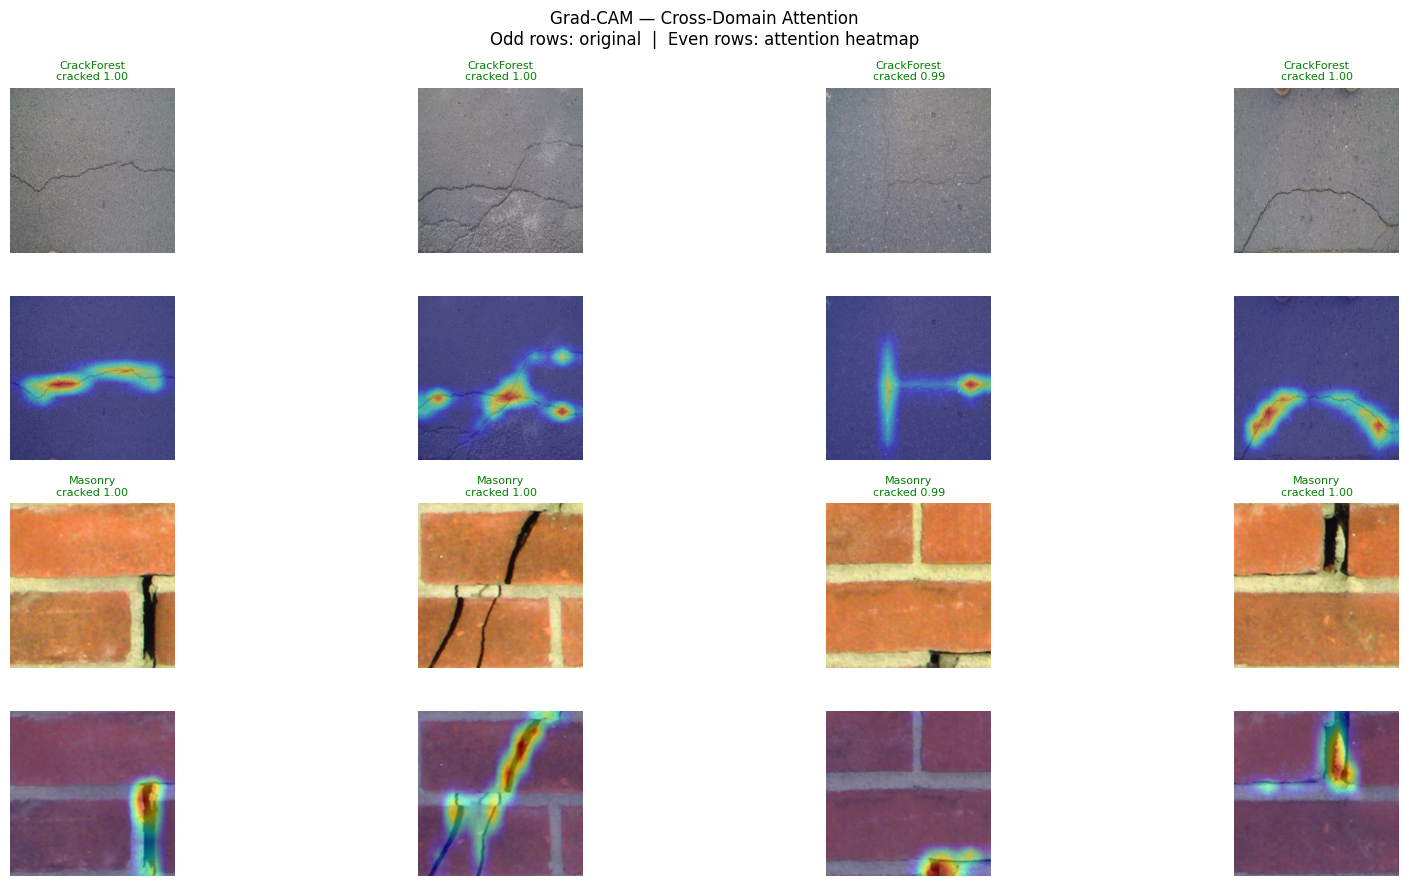

In [9]:
# Grad-CAM: what does EfficientNet-B4 attend to on unseen domains?

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, m, i, o): self.activations = o.detach()
    def _save_gradient(self, m, gi, go): self.gradients = go[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    @staticmethod
    def overlay(image_rgb, cam, alpha=0.45):
        h, w = image_rgb.shape[:2]
        cam_r   = cv2.resize(cam, (w, h))
        heatmap = cv2.applyColorMap((cam_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        return (alpha * heatmap + (1 - alpha) * image_rgb).astype(np.uint8)


grad_cam = GradCAM(clf_model, clf_model.features[-1])
tf_cls   = cls_eval_transform()

domains = [
    ('CrackForest', cf_res['paths'][:4]),
    ('Masonry',     ms_res['paths'][:4]),
]

fig, axes = plt.subplots(len(domains) * 2, 4, figsize=(18, 9))
fig.suptitle(
    'Grad-CAM — Cross-Domain Attention\n'
    'Odd rows: original  |  Even rows: attention heatmap',
    fontsize=12)

for d_row, (dname, paths) in enumerate(domains):
    for col, img_path in enumerate(list(paths)[:4]):
        img     = cv2.imread(str(img_path))
        img     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_224 = cv2.resize(img, (224, 224))
        img_t   = tf_cls(image=img)['image']
        x       = img_t.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            probs = torch.softmax(clf_model(x), dim=1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())
        cam      = grad_cam(x, class_idx=pred_idx)
        overlay  = GradCAM.overlay(img_224, cam)

        color = 'green' if pred_idx == 1 else 'red'
        top   = d_row * 2
        bot   = d_row * 2 + 1
        axes[top, col].imshow(img_224)
        axes[top, col].set_title(
            f'{dname}\n{CLS_CLASSES[pred_idx]} {probs[pred_idx]:.2f}',
            fontsize=8, color=color)
        axes[top, col].axis('off')
        axes[bot, col].imshow(overlay)
        axes[bot, col].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'clf_gradcam_cross.png', dpi=150)
plt.show()

## 2. Segmentor — Cross-Dataset Evaluation

**Model:** U-Net + ResNet34 (trained on Masonry + CrackForest combined)  
**Quantitative:** Per-source breakdown of the test split (reconstructed with seed=42)  
**Qualitative:** Predictions on HistoricalCrack/cracked (unseen domain, no ground-truth masks)

In [10]:
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from collections import Counter

SEG_IMG_SIZE = 384


def seg_eval_transform():
    return A.Compose([
        A.Resize(SEG_IMG_SIZE, SEG_IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


class CrackSegDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs     = pairs
        self.transform = transform or seg_eval_transform()

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img  = cv2.imread(str(img_path))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        out  = self.transform(image=img, mask=mask)
        return out['image'], out['mask'].unsqueeze(0)


def collect_pairs(dataset_dirs):
    pairs, labels = [], []
    for d in dataset_dirs:
        img_dir  = Path(d) / 'images'
        mask_dir = Path(d) / 'masks'
        label    = Path(d).name
        for img_path in sorted(img_dir.glob('*.*')):
            mask_path = mask_dir / f"{img_path.stem}.png"
            if mask_path.exists():
                pairs.append((img_path, mask_path))
                labels.append(label)
    return pairs, labels


def evaluate_segmentor(model, pairs, batch_size=8, desc=''):
    ds     = CrackSegDataset(pairs)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    all_tp, all_fp, all_fn, all_tn = [], [], [], []
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc=desc, leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds       = model(imgs)
            pred_bin    = (torch.sigmoid(preds) > 0.5).long()
            tp, fp, fn, tn = smp.metrics.get_stats(
                pred_bin, masks.long(), mode='binary')
            all_tp.append(tp); all_fp.append(fp)
            all_fn.append(fn); all_tn.append(tn)
    tp = torch.cat(all_tp); fp = torch.cat(all_fp)
    fn = torch.cat(all_fn); tn = torch.cat(all_tn)
    crack_iou = float(smp.metrics.iou_score(tp, fp, fn, tn, reduction='micro'))
    bg_iou    = float(smp.metrics.iou_score(tn, fn, fp, tp, reduction='micro'))
    dice      = float(smp.metrics.f1_score(tp, fp, fn, tn, reduction='micro'))
    return {'crack_iou': crack_iou, 'bg_iou': bg_iou,
            'miou': (crack_iou + bg_iou) / 2, 'dice': dice, 'n': len(ds)}


# Reconstruct test split (seed=42 — matches notebook 03)
all_pairs, all_labels = collect_pairs([
    DATA_DIR / 'masonry',
    DATA_DIR / 'crackforest',
])

train_p, tmp_p, train_l, tmp_l = train_test_split(
    all_pairs, all_labels, test_size=0.30, random_state=42, stratify=all_labels)
val_p, test_p, val_l, test_l = train_test_split(
    tmp_p, tmp_l, test_size=0.50, random_state=42, stratify=tmp_l)

print(f"Reconstructed test split: {len(test_p)} pairs")
print(f"  by source: {Counter(test_l)}")

# Load model
seg_model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                     in_channels=3, classes=1, activation=None).to(DEVICE)
ckpt = torch.load(CKPT_DIR / 'segmentor/best.pth', map_location=DEVICE)
seg_model.load_state_dict(ckpt['model_state'])
seg_model.eval()
print(f"Segmentor loaded  epoch={ckpt['epoch']}  val_iou={ckpt['val_iou']:.4f}  val_dice={ckpt['val_dice']:.4f}")

Reconstructed test split: 54 pairs
  by source: Counter({'masonry': 36, 'crackforest': 18})
Segmentor loaded  epoch=94  val_iou=0.7429  val_dice=0.8523


In [11]:
# Per-source breakdown of the test split
cf_test_pairs = [(p, m) for (p, m), l in zip(test_p, test_l) if l == 'crackforest']
ms_test_pairs = [(p, m) for (p, m), l in zip(test_p, test_l) if l == 'masonry']

print(f"CrackForest test pairs : {len(cf_test_pairs)}")
print(f"Masonry test pairs     : {len(ms_test_pairs)}")

print('\n=== Segmentor on CrackForest test split ===')
cf_seg_res = evaluate_segmentor(seg_model, cf_test_pairs, desc='CrackForest')
print(f"mIoU (2-class) : {cf_seg_res['miou']:.4f}")
print(f"Crack IoU      : {cf_seg_res['crack_iou']:.4f}")
print(f"Dice           : {cf_seg_res['dice']:.4f}")

print('\n=== Segmentor on Masonry test split ===')
ms_seg_res = evaluate_segmentor(seg_model, ms_test_pairs, desc='Masonry')
print(f"mIoU (2-class) : {ms_seg_res['miou']:.4f}")
print(f"Crack IoU      : {ms_seg_res['crack_iou']:.4f}")
print(f"Dice           : {ms_seg_res['dice']:.4f}")

CrackForest test pairs : 18
Masonry test pairs     : 36

=== Segmentor on CrackForest test split ===


CrackForest:   0%|          | 0/3 [00:00<?, ?it/s]

mIoU (2-class) : 0.7361
Crack IoU      : 0.4878
Dice           : 0.6558

=== Segmentor on Masonry test split ===


Masonry:   0%|          | 0/5 [00:00<?, ?it/s]

mIoU (2-class) : 0.8692
Crack IoU      : 0.7501
Dice           : 0.8572


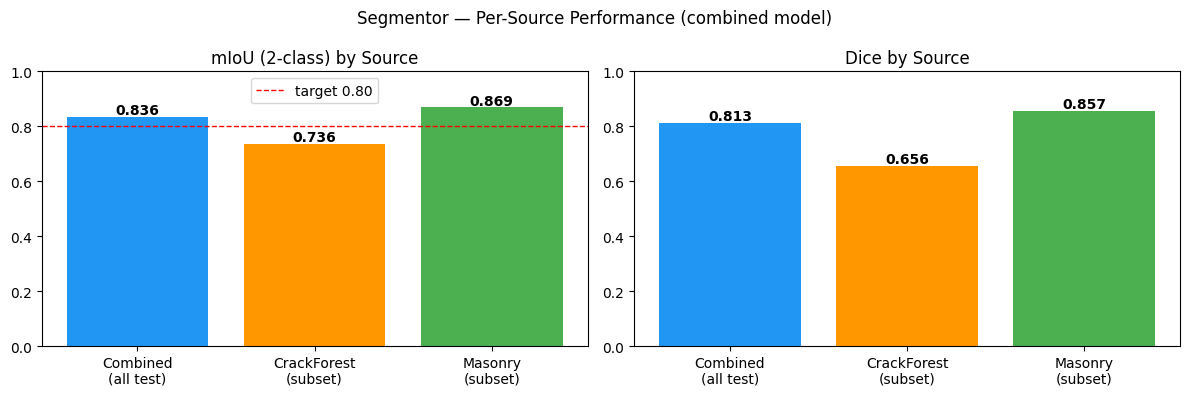

In [12]:
# ── Quantitative bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Segmentor — Per-Source Performance (combined model)', fontsize=12)

datasets_seg   = ['Combined\n(all test)', 'CrackForest\n(subset)', 'Masonry\n(subset)']
combined_miou  = 0.8356
combined_dice  = 0.8126
mious  = [combined_miou, cf_seg_res['miou'], ms_seg_res['miou']]
dices  = [combined_dice, cf_seg_res['dice'], ms_seg_res['dice']]
colors = ['#2196F3', '#FF9800', '#4CAF50']

bars1 = axes[0].bar(datasets_seg, mious, color=colors)
axes[0].set_ylim(0, 1.0)
axes[0].axhline(0.80, color='red', linestyle='--', linewidth=1, label='target 0.80')
axes[0].set_title('mIoU (2-class) by Source')
axes[0].legend()
for bar, val in zip(bars1, mious):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(datasets_seg, dices, color=colors)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Dice by Source')
for bar, val in zip(bars2, dices):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'seg_cross_summary.png', dpi=150)
plt.show()

HistoricalCrack/cracked images: 757


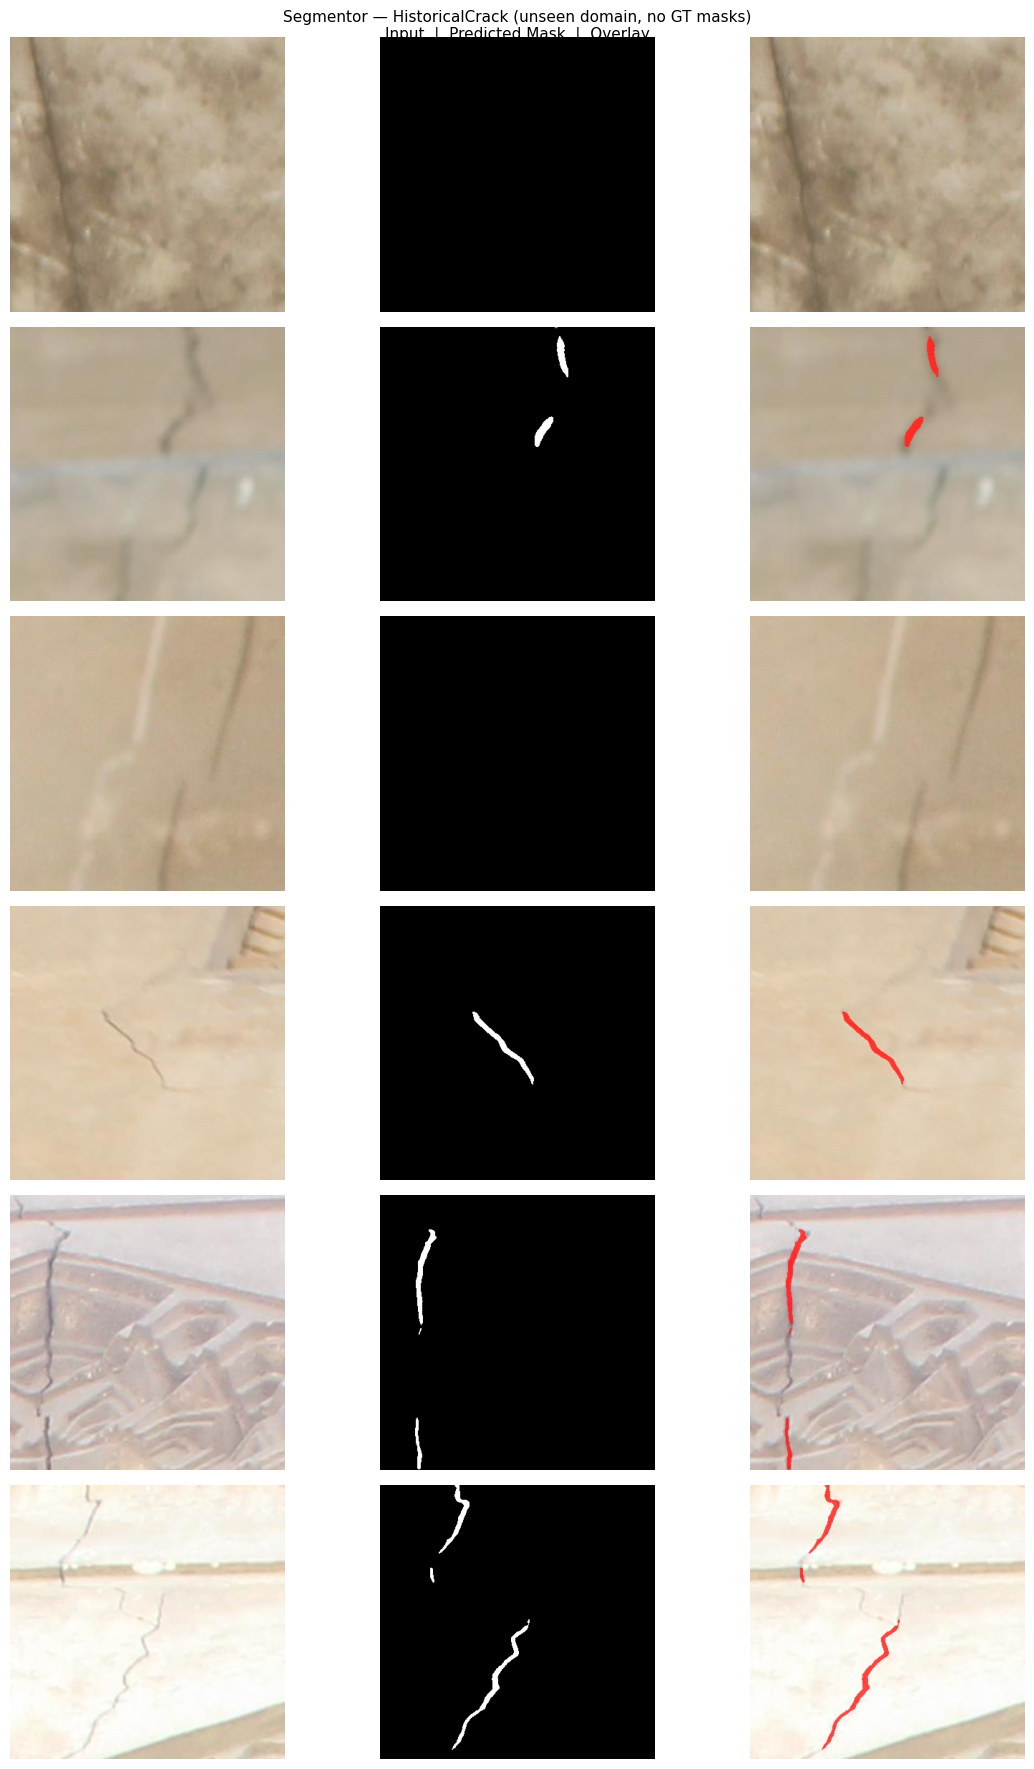

In [13]:
# ── Qualitative: HistoricalCrack (unseen domain, no masks) ───────────────
HC_CRACKED_DIR = DATA_DIR / 'historical_crack' / 'cracked'
hc_paths = sorted(HC_CRACKED_DIR.glob('*.jpg')) + sorted(HC_CRACKED_DIR.glob('*.png'))
print(f"HistoricalCrack/cracked images: {len(hc_paths)}")

sample_n   = 6
sample_idx = random.sample(range(len(hc_paths)), min(sample_n, len(hc_paths)))

INV_MEAN_SEG = np.array(IMAGENET_MEAN)
INV_STD_SEG  = np.array(IMAGENET_STD)
tf_seg       = seg_eval_transform()

fig, axes = plt.subplots(len(sample_idx), 3, figsize=(12, 3 * len(sample_idx)))
fig.suptitle('Segmentor — HistoricalCrack (unseen domain, no GT masks)\n'
             'Input  |  Predicted Mask  |  Overlay', fontsize=11)

seg_model.eval()
for row, idx in enumerate(sample_idx):
    img = cv2.imread(str(hc_paths[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_t = tf_seg(image=img)['image']
    with torch.no_grad():
        pred = torch.sigmoid(seg_model(img_t.unsqueeze(0).to(DEVICE)))
    pred_prob = pred.squeeze().cpu().numpy()
    pred_mask = (pred_prob > 0.5).astype(np.uint8)
    img_np    = (img_t.permute(1, 2, 0).numpy() * INV_STD_SEG + INV_MEAN_SEG).clip(0, 1)

    # Overlay: red channel for cracks
    overlay   = img_np.copy()
    overlay[pred_mask == 1, 0] = 1.0
    overlay[pred_mask == 1, 1] *= 0.3
    overlay[pred_mask == 1, 2] *= 0.3

    axes[row, 0].imshow(img_np);      axes[row, 0].axis('off')
    axes[row, 1].imshow(pred_mask, cmap='gray'); axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay);     axes[row, 2].axis('off')
    crack_pct = pred_mask.mean() * 100
    axes[row, 0].set_xlabel(f'crack area: {crack_pct:.1f}%', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'seg_cross_qualitative.png', dpi=150)
plt.show()

## 3. Detector — Cross-Dataset Evaluation

**Model:** YOLOv8s (trained on OmniCrack30k)  
**Cross-tested on:** CrackForest (118 images), Masonry (240 images)

Binary segmentation masks are converted to YOLO bounding boxes via contour detection (same pipeline as training).

In [14]:
from ultralytics import YOLO

det_model = YOLO(str(CKPT_DIR / 'detector/best.pt'))
print("Detector loaded.")
det_model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Detector loaded.
Model summary: 130 layers, 11,135,987 parameters, 0 gradients, 28.6 GFLOPs


(130, 11135987, 0, 28.6469632)

In [15]:
def mask_to_yolo_labels(mask_path, min_area=50):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    labels = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        cx = (x + bw / 2) / w
        cy = (y + bh / 2) / h
        labels.append(f"0 {cx:.6f} {cy:.6f} {min(bw/w, 1.):.6f} {min(bh/h, 1.):.6f}")
    return labels


def prepare_yolo_dataset(dataset_dir, out_dir, name):
    dataset_dir = Path(dataset_dir)
    out_dir     = Path(out_dir) / name
    (out_dir / 'images').mkdir(parents=True, exist_ok=True)
    (out_dir / 'labels').mkdir(parents=True, exist_ok=True)

    img_dir   = dataset_dir / 'images'
    mask_dir  = dataset_dir / 'masks'
    img_paths = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png'))

    for img_path in img_paths:
        mask_path = mask_dir / f"{img_path.stem}.png"
        labels    = mask_to_yolo_labels(mask_path) if mask_path.exists() else []
        (out_dir / 'labels' / f"{img_path.stem}.txt").write_text('\n'.join(labels))
        dst_img = out_dir / 'images' / img_path.name
        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)

    yaml_path = out_dir / 'data.yaml'
    yaml_path.write_text(
        f"path: {out_dir}\n"
        f"train: images\n"
        f"val: images\n"
        f"test: images\n"
        f"nc: 1\n"
        f"names: ['crack']\n"
    )
    print(f"{name}: {len(img_paths)} images, labels written")
    return yaml_path


YOLO_OUT = Path('/content/yolo_cross')
cf_yaml  = prepare_yolo_dataset(DATA_DIR / 'crackforest', YOLO_OUT, 'crackforest')
ms_yaml  = prepare_yolo_dataset(DATA_DIR / 'masonry',     YOLO_OUT, 'masonry')

crackforest: 118 images, labels written
masonry: 240 images, labels written


In [16]:
print('=== Detector on CrackForest ===')
cf_det = det_model.val(
    data=str(cf_yaml),
    split='test',
    device=0,
    imgsz=640,
    verbose=False,
)
print(f"mAP@50    : {cf_det.box.map50:.4f}")
print(f"mAP@50:95 : {cf_det.box.map:.4f}")
print(f"Precision : {cf_det.box.mp:.4f}")
print(f"Recall    : {cf_det.box.mr:.4f}")

print('\n=== Detector on Masonry ===')
ms_det = det_model.val(
    data=str(ms_yaml),
    split='test',
    device=0,
    imgsz=640,
    verbose=False,
)
print(f"mAP@50    : {ms_det.box.map50:.4f}")
print(f"mAP@50:95 : {ms_det.box.map:.4f}")
print(f"Precision : {ms_det.box.mp:.4f}")
print(f"Recall    : {ms_det.box.mr:.4f}")

=== Detector on CrackForest ===
Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.1 ms, read: 612.8±247.9 MB/s, size: 27.3 KB)
val: Scanning /content/yolo_cross/crackforest/labels... 118 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 2.3Kit/s 0.1s
val: New cache created: /content/yolo_cross/crackforest/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.7it/s 2.9s
                   all        118        198       0.13      0.146     0.0476     0.0102
Speed: 2.7ms preprocess, 6.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50    : 0.0476
mAP@50:95 : 0.0102
Precision : 0.1299
Recall    : 0.1465

=== Detector on Masonry ===
Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 1

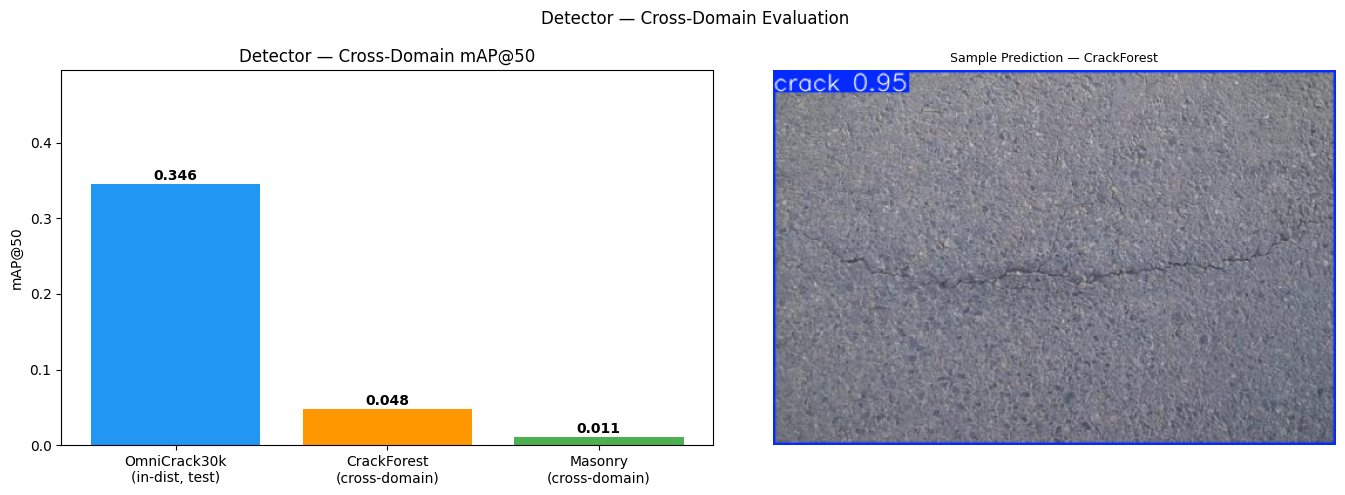

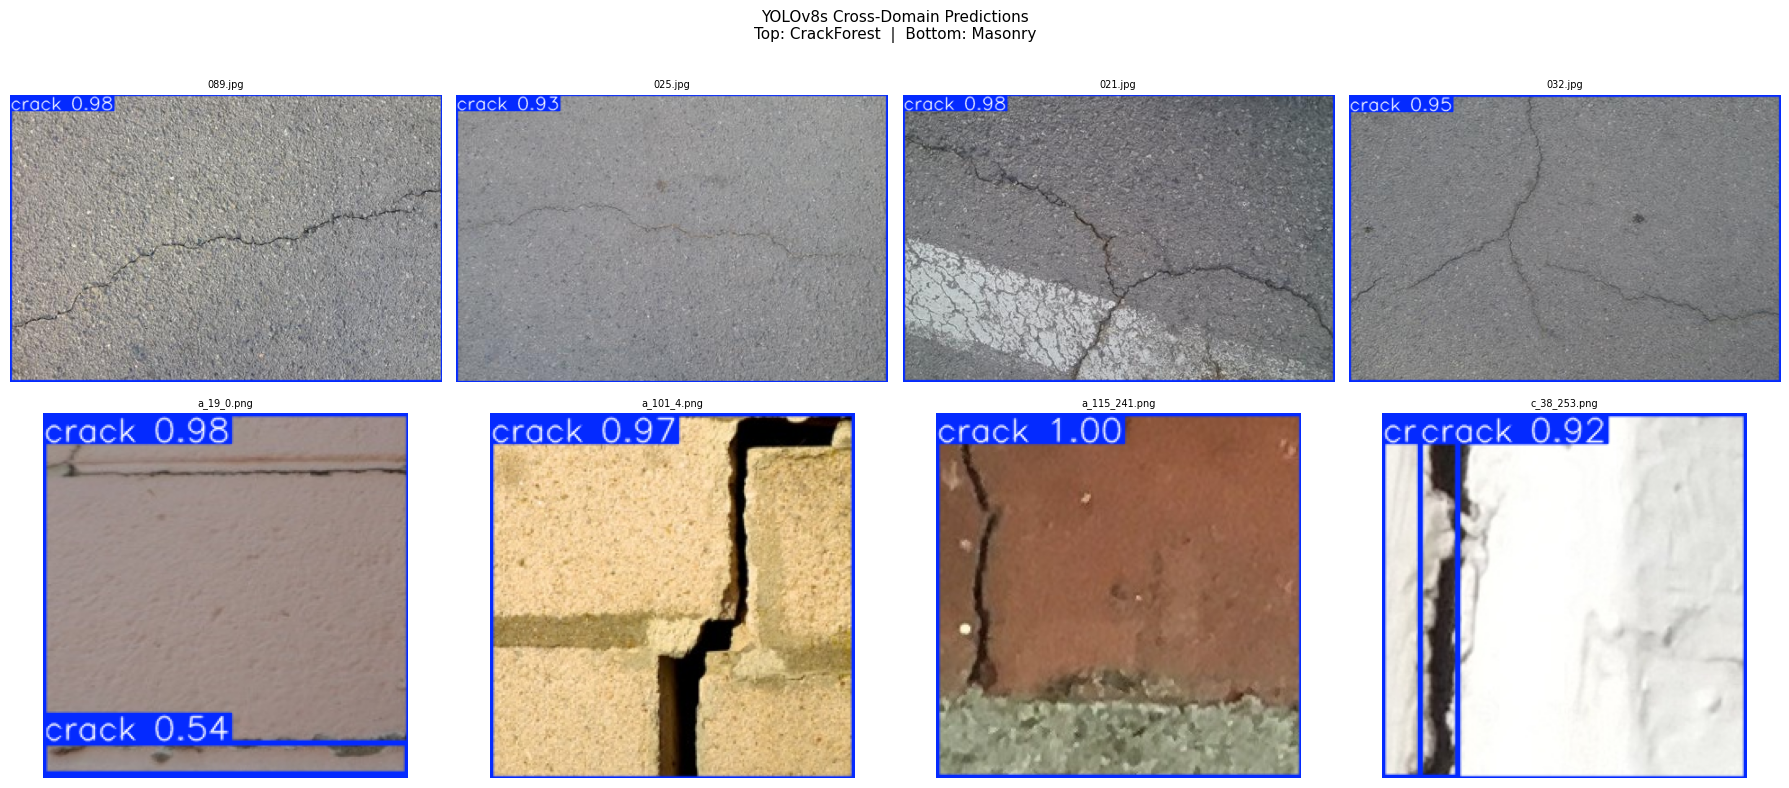

In [17]:
# ── mAP@50 bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Detector — Cross-Domain Evaluation', fontsize=12)

datasets_det = ['OmniCrack30k\n(in-dist, test)', 'CrackForest\n(cross-domain)', 'Masonry\n(cross-domain)']
maps50   = [0.3459, cf_det.box.map50, ms_det.box.map50]
colors   = ['#2196F3', '#FF9800', '#4CAF50']

bars = axes[0].bar(datasets_det, maps50, color=colors)
axes[0].set_ylim(0, max(maps50) + 0.15)
axes[0].set_ylabel('mAP@50')
axes[0].set_title('Detector — Cross-Domain mAP@50')
for bar, val in zip(bars, maps50):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Sample predictions from CrackForest
sample_paths = list((YOLO_OUT / 'crackforest' / 'images').glob('*.*'))[:4]
if sample_paths:
    r = det_model.predict(str(sample_paths[0]), conf=0.25, verbose=False)[0]
    axes[1].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    axes[1].set_title('Sample Prediction — CrackForest', fontsize=9)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'No images found', ha='center')

plt.tight_layout()
plt.savefig(OUT_DIR / 'det_cross_summary.png', dpi=150)
plt.show()

# Sample grid: 4 CrackForest, 4 Masonry
sample_cf = random.sample(list((YOLO_OUT / 'crackforest' / 'images').glob('*.*')), 4)
sample_ms = random.sample(list((YOLO_OUT / 'masonry' / 'images').glob('*.*')), 4)

fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8))
fig2.suptitle('YOLOv8s Cross-Domain Predictions\nTop: CrackForest  |  Bottom: Masonry', fontsize=11)
for col, (cf_img, ms_img) in enumerate(zip(sample_cf, sample_ms)):
    for row, img_path in enumerate([cf_img, ms_img]):
        r = det_model.predict(str(img_path), conf=0.25, verbose=False)[0]
        axes2[row, col].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
        axes2[row, col].set_title(img_path.name, fontsize=7)
        axes2[row, col].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'det_cross_predictions.png', dpi=150)
plt.show()

## 5. Cross-Domain Analysis Visualisations

Embeddings: (300, 1792)  Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete.


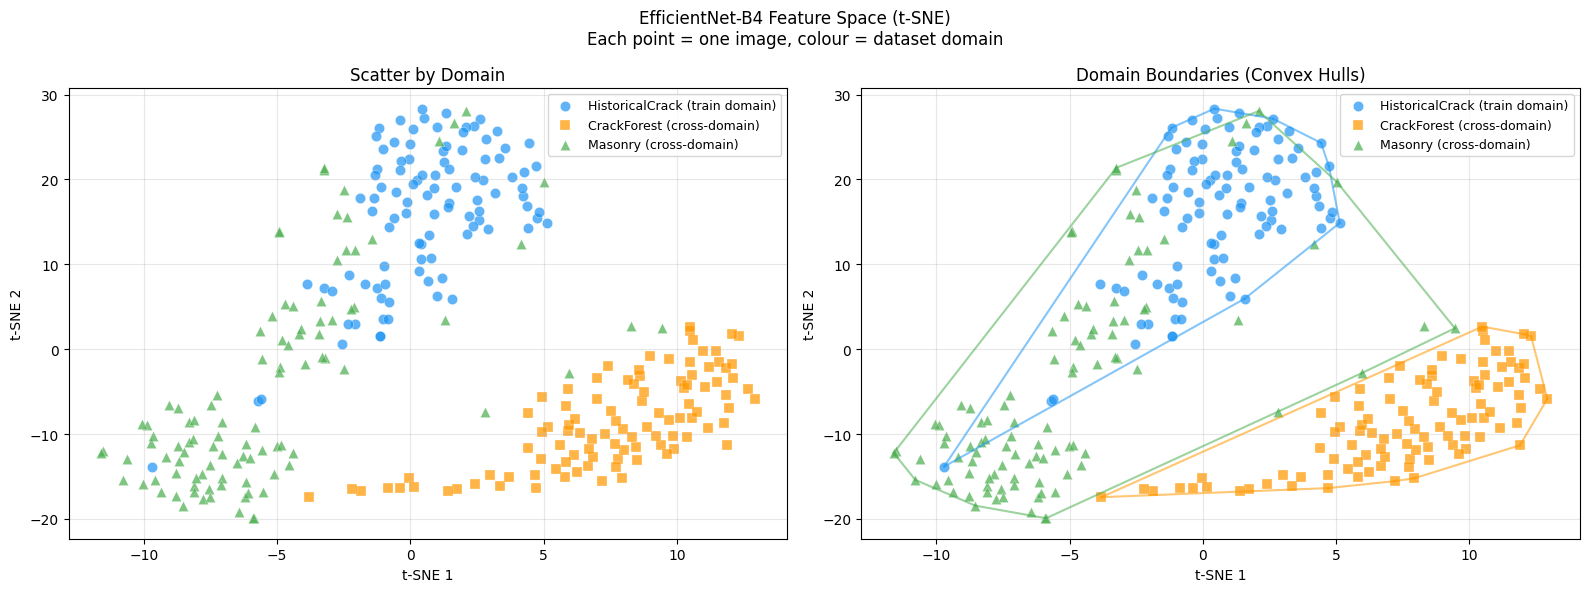

In [18]:
# t-SNE: do image domains cluster separately in EfficientNet-B4 feature space?
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull


def extract_embeddings(model, img_paths, n_samples=100, batch_size=16):
    paths  = list(img_paths)
    chosen = random.sample(paths, min(n_samples, len(paths)))
    feats  = []

    def hook_fn(module, inp, out):
        feats.append(out.detach().cpu().flatten(1).numpy())

    handle = model.avgpool.register_forward_hook(hook_fn)
    tf     = cls_eval_transform()
    batch  = []

    for p in chosen:
        img = cv2.imread(str(p))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        batch.append(tf(image=img)['image'])
        if len(batch) == batch_size:
            with torch.no_grad():
                model(torch.stack(batch).to(DEVICE))
            batch = []
    if batch:
        with torch.no_grad():
            model(torch.stack(batch).to(DEVICE))
    handle.remove()
    return np.vstack(feats) if feats else np.empty((0, 1792))


hc_paths_tsne = (
    sorted((DATA_DIR / 'historical_crack' / 'cracked').glob('*.jpg')) +
    sorted((DATA_DIR / 'historical_crack' / 'cracked').glob('*.png'))
)
hc_embs = extract_embeddings(clf_model, hc_paths_tsne,  n_samples=100)
cf_embs = extract_embeddings(clf_model, cf_res['paths'], n_samples=100)
ms_embs = extract_embeddings(clf_model, ms_res['paths'], n_samples=100)

all_embs    = np.vstack([hc_embs, cf_embs, ms_embs])
domain_tags = (
    ['HistoricalCrack'] * len(hc_embs) +
    ['CrackForest']     * len(cf_embs) +
    ['Masonry']         * len(ms_embs)
)
print(f'Embeddings: {all_embs.shape}  Running t-SNE...')

tsne   = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
embs2d = tsne.fit_transform(all_embs)
print('t-SNE complete.')

domain_cfg = {
    'HistoricalCrack': ('#2196F3', 'o', 'HistoricalCrack (train domain)'),
    'CrackForest':     ('#FF9800', 's', 'CrackForest (cross-domain)'),
    'Masonry':         ('#4CAF50', '^', 'Masonry (cross-domain)'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'EfficientNet-B4 Feature Space (t-SNE)\n'
    'Each point = one image, colour = dataset domain', fontsize=12)

for ax in axes:
    for domain, (color, marker, label) in domain_cfg.items():
        idx = [i for i, d in enumerate(domain_tags) if d == domain]
        pts = embs2d[idx]
        ax.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, label=label,
                   alpha=0.72, s=55, edgecolors='white', linewidths=0.3)

for domain, (color, marker, label) in domain_cfg.items():
    idx = [i for i, d in enumerate(domain_tags) if d == domain]
    pts = embs2d[idx]
    try:
        hull = ConvexHull(pts)
        for simplex in hull.simplices:
            axes[1].plot(pts[simplex, 0], pts[simplex, 1], '-',
                         color=color, alpha=0.55, lw=1.5)
    except Exception:
        pass

axes[0].set_title('Scatter by Domain')
axes[1].set_title('Domain Boundaries (Convex Hulls)')
for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_tsne.png', dpi=150)
plt.show()

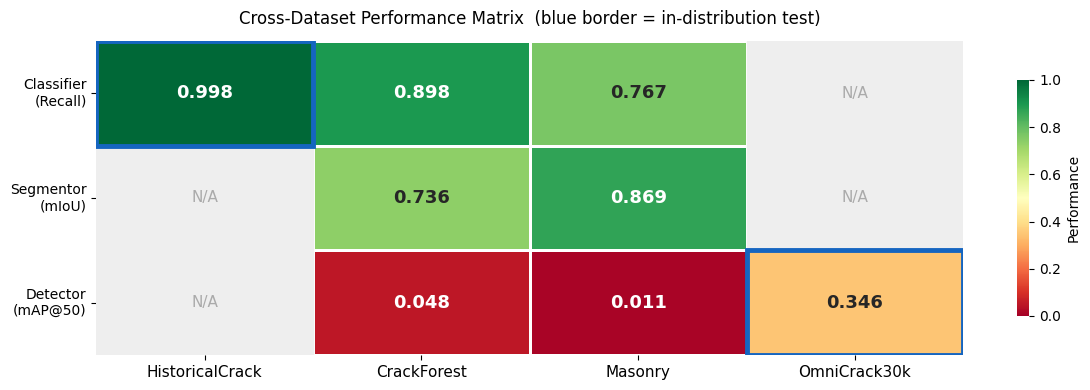

In [19]:
# Cross-dataset performance matrix (seaborn annotated heatmap)
import seaborn as sns

model_names   = ['Classifier\n(Recall)', 'Segmentor\n(mIoU)', 'Detector\n(mAP@50)']
dataset_names = ['HistoricalCrack', 'CrackForest', 'Masonry', 'OmniCrack30k']

perf = np.array([
    [0.9983,              cf_res['recall'],   ms_res['recall'],   np.nan ],
    [np.nan,              cf_seg_res['miou'], ms_seg_res['miou'], np.nan ],
    [np.nan,              cf_det.box.map50,   ms_det.box.map50,   0.3459 ],
])

in_dist = np.array([
    [True,  False, False, False],
    [False, False, False, False],
    [False, False, False, True ],
])

nan_mask = np.isnan(perf)
fig, ax  = plt.subplots(figsize=(12, 4))

sns.heatmap(
    perf, mask=nan_mask,
    annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
    xticklabels=dataset_names, yticklabels=model_names,
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Performance', 'shrink': 0.75},
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=ax,
)

for i in range(perf.shape[0]):
    for j in range(perf.shape[1]):
        if nan_mask[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#EEEEEE', zorder=2))
            ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                    fontsize=11, color='#AAAAAA', zorder=3)

for i in range(perf.shape[0]):
    for j in range(perf.shape[1]):
        if in_dist[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor='#1565C0', lw=3.5, zorder=4))

ax.set_title(
    'Cross-Dataset Performance Matrix  (blue border = in-distribution test)',
    fontsize=12, pad=12)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cross_eval_heatmap.png', dpi=150)
plt.show()

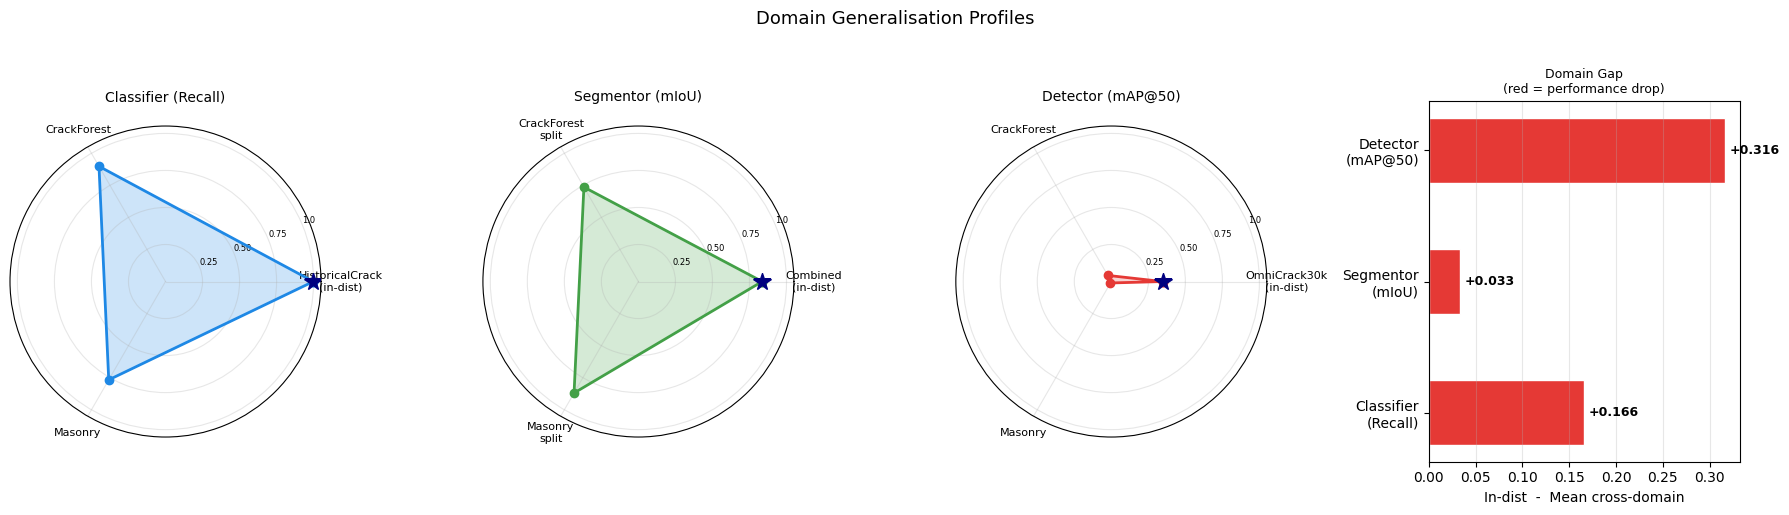

In [20]:
# Radar charts per model + domain gap bar chart
fig = plt.figure(figsize=(18, 5))
fig.suptitle('Domain Generalisation Profiles', fontsize=13, y=1.02)

radar_configs = [
    {
        'title':  'Classifier (Recall)',
        'labels': ['HistoricalCrack\n(in-dist)', 'CrackForest', 'Masonry'],
        'values': [0.9983, cf_res['recall'], ms_res['recall']],
        'color':  '#1E88E5',
    },
    {
        'title':  'Segmentor (mIoU)',
        'labels': ['Combined\n(in-dist)', 'CrackForest\nsplit', 'Masonry\nsplit'],
        'values': [0.8356, cf_seg_res['miou'], ms_seg_res['miou']],
        'color':  '#43A047',
    },
    {
        'title':  'Detector (mAP@50)',
        'labels': ['OmniCrack30k\n(in-dist)', 'CrackForest', 'Masonry'],
        'values': [0.3459, cf_det.box.map50, ms_det.box.map50],
        'color':  '#E53935',
    },
]

for k, cfg in enumerate(radar_configs):
    ax = fig.add_subplot(1, 4, k + 1, polar=True)
    N      = len(cfg['labels'])
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    vals   = cfg['values'] + [cfg['values'][0]]
    angs   = angles + angles[:1]

    ax.fill(angs, vals, alpha=0.22, color=cfg['color'])
    ax.plot(angs, vals, 'o-', color=cfg['color'], lw=2, ms=6)
    ax.plot([angs[0]], [vals[0]], '*', color='navy', ms=13, zorder=5)

    ax.set_thetagrids(np.degrees(angles), cfg['labels'], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=6)
    ax.set_title(cfg['title'], size=10, pad=18)
    ax.grid(True, alpha=0.3)

ax4 = fig.add_subplot(1, 4, 4)
gap_models     = ['Classifier\n(Recall)', 'Segmentor\n(mIoU)', 'Detector\n(mAP@50)']
in_dist_scores = [0.9983, 0.8356, 0.3459]
cross_scores   = [
    (cf_res['recall']   + ms_res['recall'])   / 2,
    (cf_seg_res['miou'] + ms_seg_res['miou']) / 2,
    (cf_det.box.map50   + ms_det.box.map50)   / 2,
]
gaps = [i - c for i, c in zip(in_dist_scores, cross_scores)]

bar_colors = ['#E53935' if g > 0 else '#43A047' for g in gaps]
bars = ax4.barh(gap_models, gaps, color=bar_colors, edgecolor='white', height=0.5)
ax4.axvline(0, color='black', lw=1.2)
for bar, val in zip(bars, gaps):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax4.text(xpos, bar.get_y() + bar.get_height() / 2,
             f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax4.set_xlabel('In-dist  -  Mean cross-domain')
ax4.set_title('Domain Gap\n(red = performance drop)', fontsize=9)
ax4.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'domain_radar_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Summary

In [21]:
print("=" * 70)
print(f"{'CROSS-DATASET EVALUATION SUMMARY':^70}")
print("=" * 70)
print()

header = f"{'Task':<16}{'Trained on':<22}{'Tested on':<22}{'Metric':<12}{'Score'}"
print(header)
print("-" * 80)

rows = [
    ('Classification', 'HistoricalCrack',  'HistoricalCrack*',  'Recall',  '0.9983'),
    ('',               '',                 'CrackForest',       'Recall',  f"{cf_res['recall']:.4f}"),
    ('',               '',                 'Masonry',           'Recall',  f"{ms_res['recall']:.4f}"),
    ('Segmentation',   'Masonry+CrackFor', 'Test (combined)*',  'mIoU',    '0.8356'),
    ('',               '',                 'CrackForest split', 'mIoU',    f"{cf_seg_res['miou']:.4f}"),
    ('',               '',                 'Masonry split',     'mIoU',    f"{ms_seg_res['miou']:.4f}"),
    ('',               '',                 'HistoricalCrack',   'mIoU',    'qualitative'),
    ('Detection',      'OmniCrack30k',     'OmniCrack30k*',    'mAP@50',  '0.3459'),
    ('',               '',                 'CrackForest',       'mAP@50',  f'{cf_det.box.map50:.4f}'),
    ('',               '',                 'Masonry',           'mAP@50',  f'{ms_det.box.map50:.4f}'),
]

for task, train, test, metric, score in rows:
    print(f"{task:<16}{train:<22}{test:<22}{metric:<12}{score}")

print()
print("* = in-distribution result from respective training notebook")

                   CROSS-DATASET EVALUATION SUMMARY                   

Task            Trained on            Tested on             Metric      Score
--------------------------------------------------------------------------------
Classification  HistoricalCrack       HistoricalCrack*      Recall      0.9983
                                      CrackForest           Recall      0.8983
                                      Masonry               Recall      0.7667
Segmentation    Masonry+CrackFor      Test (combined)*      mIoU        0.8356
                                      CrackForest split     mIoU        0.7361
                                      Masonry split         mIoU        0.8692
                                      HistoricalCrack       mIoU        qualitative
Detection       OmniCrack30k          OmniCrack30k*         mAP@50      0.3459
                                      CrackForest           mAP@50      0.0476
                                      Masonry        

In [22]:
import json

DRIVE_CROSS = DRIVE_DIR / 'cross_eval'
DRIVE_CROSS.mkdir(parents=True, exist_ok=True)

# Copy all plots
for f in sorted(OUT_DIR.glob('*.png')):
    shutil.copy2(f, DRIVE_CROSS / f.name)

# Save numeric results
results = {
    'classifier': {
        'in_dist_recall':     0.9983,
        'crackforest_recall': cf_res['recall'],
        'masonry_recall':     ms_res['recall'],
    },
    'segmentor': {
        'combined_test_miou':  0.8356,
        'combined_test_dice':  0.8126,
        'crackforest_miou':    cf_seg_res['miou'],
        'crackforest_dice':    cf_seg_res['dice'],
        'masonry_miou':        ms_seg_res['miou'],
        'masonry_dice':        ms_seg_res['dice'],
    },
    'detector': {
        'omnicrack_map50':      0.3459,
        'crackforest_map50':    float(cf_det.box.map50),
        'crackforest_map5095':  float(cf_det.box.map),
        'masonry_map50':        float(ms_det.box.map50),
        'masonry_map5095':      float(ms_det.box.map),
    },
}

(DRIVE_CROSS / 'cross_eval_results.json').write_text(json.dumps(results, indent=2))

print("Saved to Drive:")
for f in sorted(DRIVE_CROSS.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.2f} MB)")

print("\nCross-dataset evaluation complete!")

Saved to Drive:
  clf_cross_predictions.png  (1.89 MB)
  clf_cross_summary.png  (0.07 MB)
  clf_gradcam_cross.png  (1.55 MB)
  cross_eval_heatmap.png  (0.07 MB)
  cross_eval_results.json  (0.00 MB)
  det_cross_predictions.png  (2.38 MB)
  det_cross_summary.png  (0.62 MB)
  domain_radar_gap.png  (0.25 MB)
  feature_tsne.png  (0.19 MB)
  seg_cross_qualitative.png  (0.84 MB)
  seg_cross_summary.png  (0.06 MB)

Cross-dataset evaluation complete!
